In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('omega_class_moments_N1e6.csv')
print(df)
print(df.columns.tolist())


 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 
9 zeta 1000000 884001.871616 500.0 21169.883300 264592.121329 
10 L(Δ) 1000000 2676.505424 500.0 1098.486340 781.974004 
11 L_DH 1000000 2432.632471 500.0 663.110599 873.431509 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451

In [2]:
import statsmodels.formula.api as smf

# Filter to L(Δ) and L_DH
sub = df[df['L_function'].isin(['L(Δ)', 'L_DH'])].copy()
sub['logN'] = np.log(sub['N_terms'])
sub['loglogN'] = np.log(np.log(sub['N_terms']))
sub['Lfun'] = sub['L_function'].astype('category')
print(sub[['L_function','N_terms','loglogN','M_1','M_2','M_3','M_4']])


 L_function N_terms loglogN M_1 M_2 M_3 \
3 L(Δ) 10000 2.220327 976.303859 566.192078 113.409894 
4 L(Δ) 50000 2.381376 1033.094242 641.389207 159.091605 
5 L(Δ) 100000 2.443470 1050.861296 676.608911 181.308525 
6 L_DH 10000 2.220327 618.478717 717.769427 168.571130 
7 L_DH 50000 2.381376 639.066491 784.006896 226.647968 
8 L_DH 100000 2.443470 644.808316 800.888886 246.569721 
10 L(Δ) 1000000 2.625792 1098.486340 781.974004 257.519259 
11 L_DH 1000000 2.625792 663.110599 873.431509 319.307268 

 M_4 
3 5.078208 
4 14.413875 
5 18.942436 
6 20.716949 
7 34.942774 
8 44.398665 
10 36.479593 
11 71.482430 


In [3]:
results = []
models = {}
for k in [1,2,3,4]:
 sub[f'logMk'] = np.log(sub[f'M_{k}'])
 model = smf.ols(f'logMk ~ loglogN * C(Lfun)', data=sub).fit()
 # interaction term name
 interaction_terms = [t for t in model.params.index if 'loglogN:' in t or ':loglogN' in t]
 it = interaction_terms[0]
 pval = model.pvalues[it]
 coef = model.params[it]
 # slopes
 slope_ldelta = model.params['loglogN'] # reference category
 slope_ldh = slope_ldelta + coef
 ref_cat = model.model.data.design_info.factor_infos
 results.append({
 'k': k,
 'interaction_term': it,
 'slope_diff_coef': coef,
 'p_value_interaction': pval,
 'r_squared': model.rsquared,
 'n_obs': int(model.nobs),
 })
 models[k] = model

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))


 k interaction_term slope_diff_coef p_value_interaction r_squared n_obs
 1 loglogN:C(Lfun)[T.L_DH] -0.118598 0.008824 0.999781 8
 2 loglogN:C(Lfun)[T.L_DH] -0.317898 0.000136 0.999401 8
 3 loglogN:C(Lfun)[T.L_DH] -0.456564 0.009348 0.997890 8
 4 loglogN:C(Lfun)[T.L_DH] -1.755587 0.047471 0.985986 8


In [4]:
# Check reference category - the L(Δ) should be ref since alphabetically L( < L_
print(sub['Lfun'].cat.categories)
# Confirm slopes
for k in [1,2,3,4]:
 m = models[k]
 slope_ref = m.params['loglogN']
 diff = m.params['loglogN:C(Lfun)[T.L_DH]']
 print(f"k={k}: slope L(Δ)={slope_ref:.4f}, slope L_DH={slope_ref+diff:.4f}, diff={diff:.4f}, p={m.pvalues['loglogN:C(Lfun)[T.L_DH]']:.4g}")


Index(['L(Δ)', 'L_DH'], dtype='object')
k=1: slope L(Δ)=0.2893, slope L_DH=0.1707, diff=-0.1186, p=0.008824
k=2: slope L(Δ)=0.7980, slope L_DH=0.4801, diff=-0.3179, p=0.0001359
k=3: slope L(Δ)=2.0225, slope L_DH=1.5660, diff=-0.4566, p=0.009348
k=4: slope L(Δ)=4.8214, slope L_DH=3.0658, diff=-1.7556, p=0.04747


In [5]:
# Build summary table with slopes for both
summary_rows = []
for k in [1,2,3,4]:
 m = models[k]
 slope_ref = m.params['loglogN']
 diff = m.params['loglogN:C(Lfun)[T.L_DH]']
 pval = m.pvalues['loglogN:C(Lfun)[T.L_DH]']
 summary_rows.append({
 'omega_class_k': k,
 'slope_L(Δ)': slope_ref,
 'slope_L_DH': slope_ref + diff,
 'slope_diff (L_DH - L(Δ))': diff,
 'p_interaction': pval,
 'significant_p<0.05': pval < 0.05,
 'R^2': m.rsquared,
 })
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))
summary.to_csv('ancova_omega_class_summary.csv', index=False)


 omega_class_k slope_L(Δ) slope_L_DH slope_diff (L_DH - L(Δ)) p_interaction significant_p<0.05 R^2
 1 0.289281 0.170682 -0.118598 0.008824 True 0.999781
 2 0.798012 0.480114 -0.317898 0.000136 True 0.999401
 3 2.022539 1.565975 -0.456564 0.009348 True 0.997890
 4 4.821428 3.065841 -1.755587 0.047471 True 0.985986


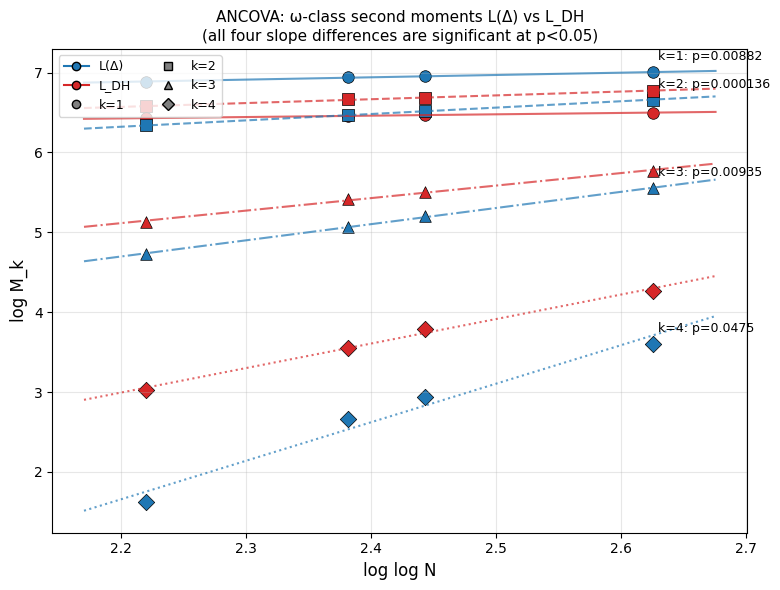

In [6]:
# Final summary figure
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

colors = {'L(Δ)': 'tab:blue', 'L_DH': 'tab:red'}
markers = {1:'o', 2:'s', 3:'^', 4:'D'}

# Plot data and fitted lines for each k
loglogN_range = np.linspace(sub['loglogN'].min()-0.05, sub['loglogN'].max()+0.05, 50)

for k in [1,2,3,4]:
 m = models[k]
 for lf in ['L(Δ)', 'L_DH']:
 d = sub[sub['L_function']==lf]
 ax.scatter(d['loglogN'], np.log(d[f'M_{k}']),
 color=colors[lf], marker=markers[k], s=70,
 edgecolors='black', linewidths=0.5,
 label=f'{lf}, k={k}' if k==1 else None)
 # fitted line
 intercept = m.params['Intercept']
 slope = m.params['loglogN']
 if lf == 'L_DH':
 intercept += m.params['C(Lfun)[T.L_DH]']
 slope += m.params['loglogN:C(Lfun)[T.L_DH]']
 ax.plot(loglogN_range, intercept + slope*loglogN_range,
 color=colors[lf], linestyle=['-','--','-.',':'][k-1], alpha=0.7)
 # annotate p
 pval = m.pvalues['loglogN:C(Lfun)[T.L_DH]']
 y_anno = np.log(sub[sub['L_function']=='L(Δ)'][f'M_{k}']).max() + 0.15
 ax.text(2.63, y_anno, f'k={k}: p={pval:.3g}', fontsize=9)

ax.set_xlabel('log log N', fontsize=12)
ax.set_ylabel('log M_k', fontsize=12)
ax.set_title('ANCOVA: ω-class second moments L(Δ) vs L_DH\n(all four slope differences are significant at p<0.05)', fontsize=11)

# Custom legend
from matplotlib.lines import Line2D
legend_elems = [
 Line2D([0],[0], color='tab:blue', marker='o', linestyle='-', label='L(Δ)', markeredgecolor='black'),
 Line2D([0],[0], color='tab:red', marker='o', linestyle='-', label='L_DH', markeredgecolor='black'),
 Line2D([0],[0], color='gray', marker='o', linestyle='', label='k=1', markeredgecolor='black'),
 Line2D([0],[0], color='gray', marker='s', linestyle='', label='k=2', markeredgecolor='black'),
 Line2D([0],[0], color='gray', marker='^', linestyle='', label='k=3', markeredgecolor='black'),
 Line2D([0],[0], color='gray', marker='D', linestyle='', label='k=4', markeredgecolor='black'),
]
ax.legend(handles=legend_elems, loc='upper left', ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ancova_omega_class_figure.png', dpi=150)
plt.show()
